In [2]:
from qiskit import __version__

print(__version__)

2.5.2


In [32]:
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram, array_to_latex
from qiskit.result import marginal_distribution
from qiskit.circuit.library import UGate
from math import pi
import random
from qiskit.circuit.classical import expr

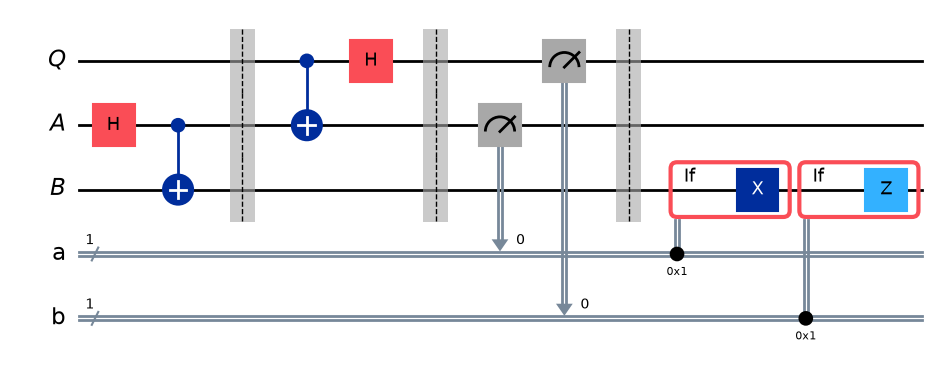

In [2]:
qubit = QuantumRegister(1, "Q")
ebit0 = QuantumRegister(1, "A")
ebit1 = QuantumRegister(1, "B")
a = ClassicalRegister(1, "a")
b = ClassicalRegister(1, "b")

protocol = QuantumCircuit(qubit, ebit0, ebit1, a, b)

#Prepare ebit
protocol.h(ebit0)
protocol.cx(ebit0, ebit1)
protocol.barrier()

#Alice
protocol.cx(qubit, ebit0)
protocol.h(qubit)
protocol.barrier()

#Alice measures and sends classical to Bob
protocol.measure(ebit0, a)
protocol.measure(qubit, b)
protocol.barrier()

#Bob uses classical bits to apply gates
with protocol.if_test((a, 1)):
    protocol.x(ebit1)
with protocol.if_test((b, 1)):
    protocol.z(ebit1)

display(protocol.draw(output="mpl"))


In [7]:
random_gate = UGate(
    theta=random.random() * 2 * pi,
    phi=random.random() * 2 * pi,
    lam=random.random() * 2 * pi,
)

display(array_to_latex(random_gate.to_matrix()))

<IPython.core.display.Latex object>

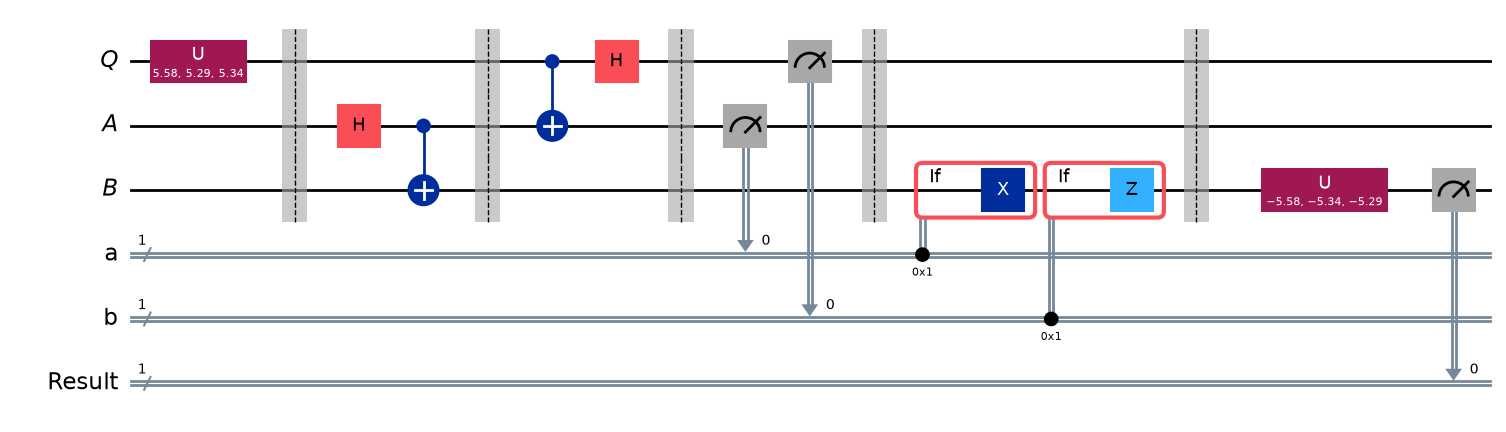

In [8]:
test = QuantumCircuit(qubit, ebit0, ebit1, a, b)

#Start w/ random gate on Q
test.append(random_gate, qubit)
test.barrier()
#Add teleportation protocol from above
test = test.compose(protocol)
test.barrier()
#Now, inverse of random unitary to B and measure
test.append(random_gate.inverse(), ebit1)
result = ClassicalRegister(1, "Result")
test.add_register(result)
test.measure(ebit1, result)
display(test.draw(output="mpl"))

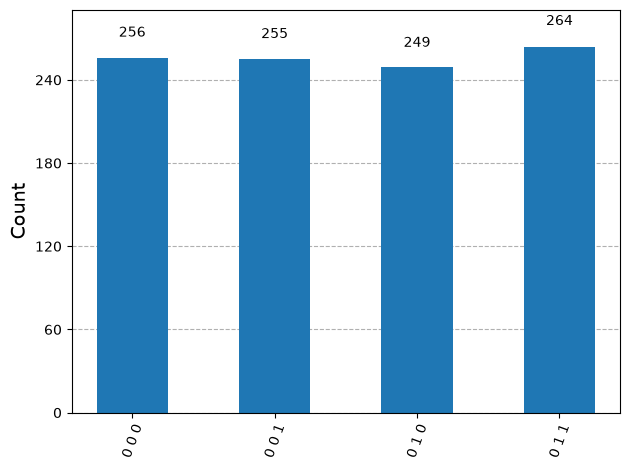

In [14]:
result = AerSimulator().run(test).result()
statistics = result.get_counts()
display(plot_histogram(statistics))

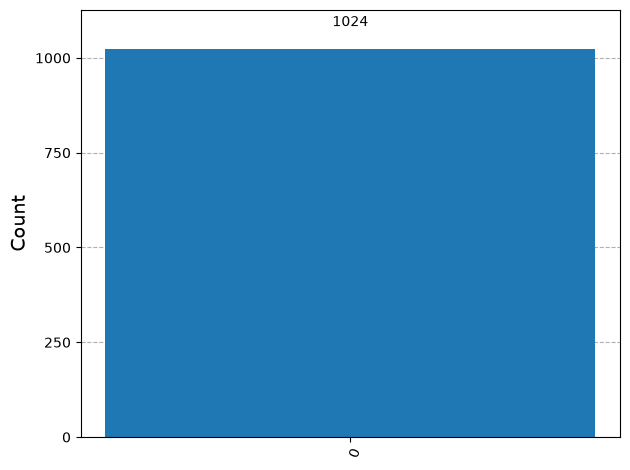

In [15]:
filtered_statistics = marginal_distribution(statistics, [2])
display(plot_histogram(filtered_statistics))

Superdense Coding

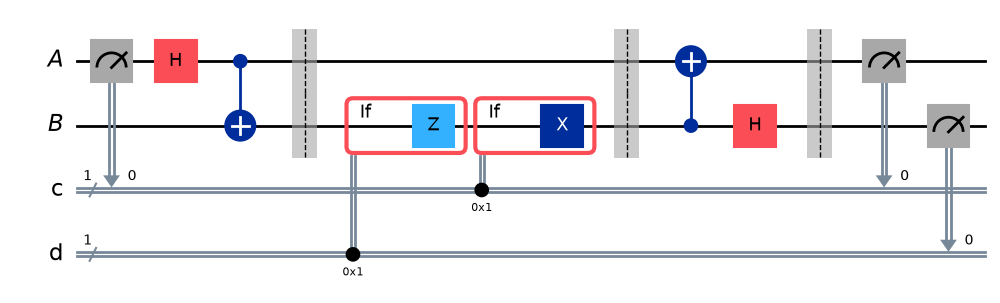

In [ ]:

c = ClassicalRegister(1, "c")
d = ClassicalRegister(1, "d")
#By default, c & d are 0
ebit1 = QuantumRegister(1, "B")

protocol = QuantumCircuit(ebit0, ebit1, c, d)
protocol.measure(ebit0[0], c[0])
protocol.store(d[0], expr.bit_not(c[0]))#Flips c to 1


#Prepare ebit
protocol.h(ebit0)
protocol.cx(ebit0, ebit1)
protocol.barrier()

with protocol.if_test((d, 1)):
    protocol.z(ebit1)
with protocol.if_test((c, 1)):
    protocol.x(ebit1)
protocol.barrier()

protocol.cx(ebit1, ebit0)
protocol.h(ebit1)

protocol.barrier()

protocol.measure(ebit0, c)
protocol.measure(ebit1, d)

display(protocol.draw(output="mpl"))

Measured 1 0 with frequency 1024


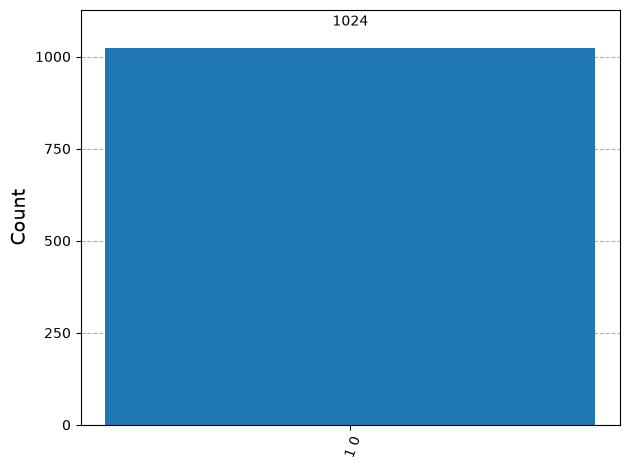

In [50]:
result = AerSimulator().run(protocol).result()
statistics = result.get_counts()

for outcome, frequency in statistics.items():
    print(f"Measured {outcome} with frequency {frequency}")

display(plot_histogram(statistics))

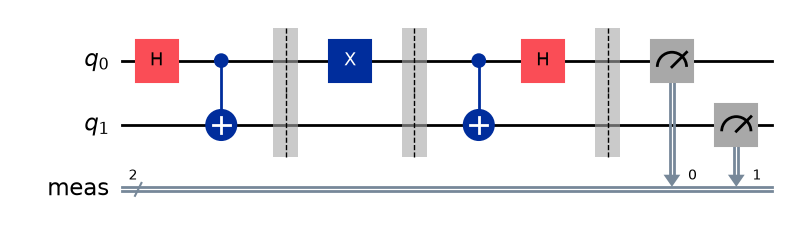

In [68]:
#True version, c and d need to be like this.
c = "1"
d = "0"

protocol = QuantumCircuit(2)

# Prepare ebit used for superdense coding
protocol.h(0)
protocol.cx(0, 1)
protocol.barrier()

# Alice's operations
if d == "1":
    protocol.z(0)
if c == "1":
    protocol.x(0)
protocol.barrier()

# Bob's actions
protocol.cx(0, 1)
protocol.h(0)
protocol.measure_all()

display(protocol.draw(output="mpl"))


Measured 10 with frequency 1024


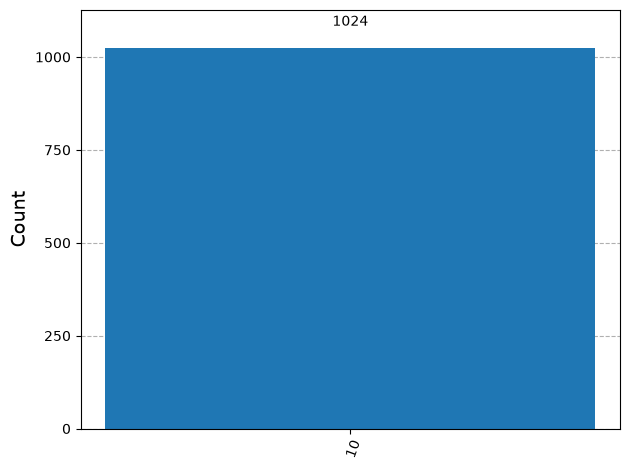

In [69]:
result = AerSimulator().run(protocol).result()
statistics = result.get_counts()

for outcome, frequency in statistics.items():
    print(f"Measured {outcome} with frequency {frequency}")

display(plot_histogram(statistics))

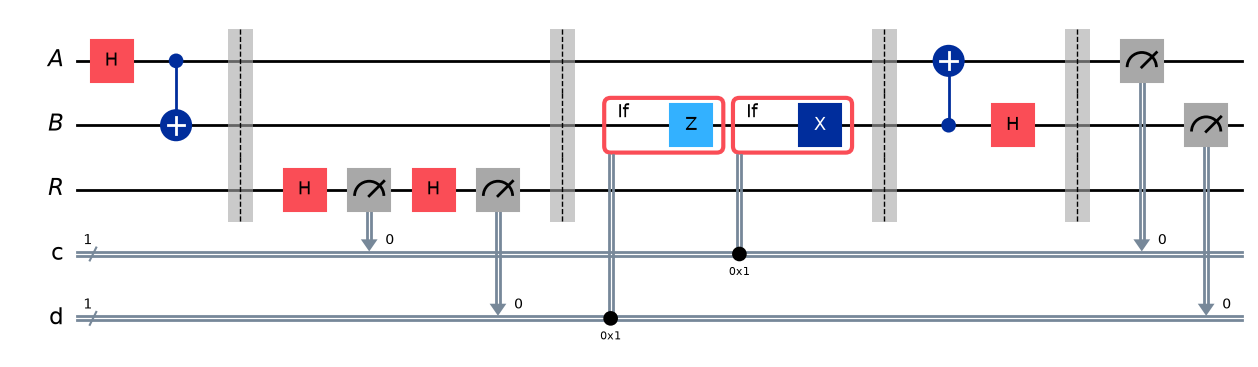

In [63]:

c = ClassicalRegister(1, "c")
d = ClassicalRegister(1, "d")
randomize = QuantumRegister(1, "R")
#By default, c & d are 0, also, operations happen on Quantum Comp, so since this is just a diagram, this doesn't work properly.
ebit0 = QuantumRegister(1, "A")
ebit1 = QuantumRegister(1, "B")

protocol = QuantumCircuit(ebit0, ebit1, randomize, c, d)


#Prepare ebit
protocol.h(ebit0)
protocol.cx(ebit0, ebit1)
protocol.barrier()

protocol.h(randomize)
protocol.measure(randomize, c)
protocol.h(randomize)
protocol.measure(randomize, d)
protocol.barrier()

with protocol.if_test((d, 1)):
    protocol.z(ebit1)
    pass
with protocol.if_test((c, 1)):
    protocol.x(ebit1)
protocol.barrier()

protocol.cx(ebit1, ebit0)
protocol.h(ebit1)

protocol.barrier()

protocol.measure(ebit0, c)
protocol.measure(ebit1, d)

display(protocol.draw(output="mpl"))

Measured 1 1 with frequency 249
Measured 1 0 with frequency 256
Measured 0 0 with frequency 257
Measured 0 1 with frequency 262


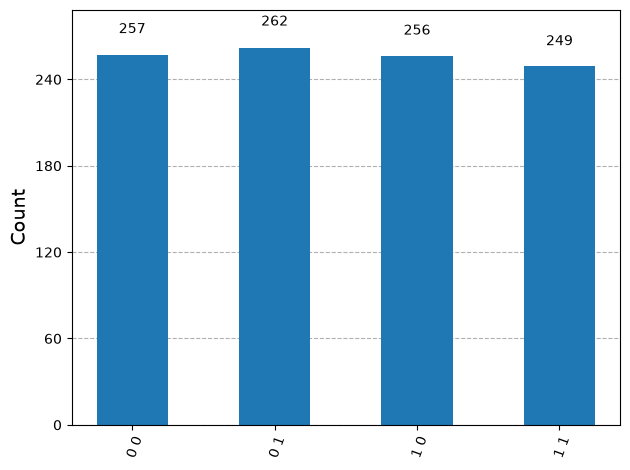

In [64]:
result = AerSimulator().run(protocol).result()
statistics = result.get_counts()

for outcome, frequency in statistics.items():
    print(f"Measured {outcome} with frequency {frequency}")

display(plot_histogram(statistics))

CHSH Game

In [70]:
def chsh_game(strategy):
    x, y = random.randint(0, 1), random.randint(0, 1)
    a, b = strategy(x, y)
    if (a!=b) == (x&y):
        return 1
    return 0

In [71]:
def chsh_circuit(x, y):
    qc = QuantumCircuit(2, 2)#circuit with 2 qubits and classical bits
    #Prepare ebit in qbits 1 and 2
    qc.h(0)
    qc.cx(0, 1)
    qc.barrier()
    #Alice's actions
    if x == 0:
        qc.ry(0,0)
    else:
        qc.ry(-pi/2,0)
    qc.measure(0, 0)

    #Bob's actions
    if y == 0:
        qc.ry(-pi/4,1)
    else:
        qc.ry(pi/4,1)
    qc.measure(1, 1)

    return qc

(x,y) = (0,0)


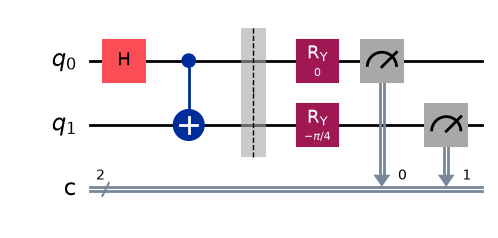

(x,y) = (0,1)


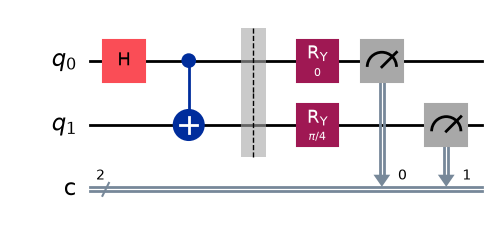

(x,y) = (1,0)


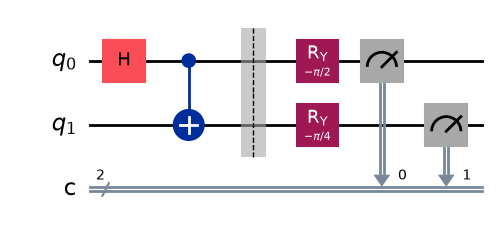

(x,y) = (1,1)


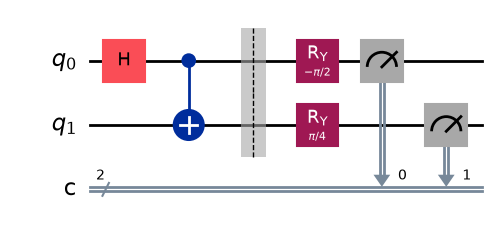

In [72]:
# Draw the four possible circuits

print("(x,y) = (0,0)")
display(chsh_circuit(0, 0).draw(output="mpl"))

print("(x,y) = (0,1)")
display(chsh_circuit(0, 1).draw(output="mpl"))

print("(x,y) = (1,0)")
display(chsh_circuit(1, 0).draw(output="mpl"))

print("(x,y) = (1,1)")
display(chsh_circuit(1, 1).draw(output="mpl"))

In [ ]:
def quantum_strategy(x, y):
    # This function runs the appropriate quantum circuit defined above
    # one time and returns the measurement results

    # Setting `shots=1` to run the circuit once
    result = AerSimulator().run(chsh_circuit(x, y), shots=1).result()
    statistics = result.get_counts()

    # Determine the output bits and return them
    bits = list(statistics.keys())[0]
    a, b = bits[0], bits[1]
    return a, b
#Runs game once with AER simulator

In [77]:
NUM_GAMES = 1000
TOTAL_SCORE = 0

for _ in range(NUM_GAMES):
    TOTAL_SCORE += chsh_game(quantum_strategy)

print("Fraction of games won:", TOTAL_SCORE / NUM_GAMES)

Fraction of games won: 0.833


In [78]:
def classical_strategy(x, y):
    # This function implements just one example of an optimal classical
    # strategy for the CHSH game. Other classical strategies can be
    # implemented by changing the bit values assigned to a and b.

    # Alice's answer
    if x == 0:
        a = 0
    elif x == 1:
        a = 1

    # Bob's answer
    if y == 0:
        b = 1
    elif y == 1:
        b = 0

    return a, b

In [79]:
NUM_GAMES = 1000
TOTAL_SCORE = 0

for _ in range(NUM_GAMES):
    TOTAL_SCORE += chsh_game(classical_strategy)

print("Fraction of games won:", TOTAL_SCORE / NUM_GAMES)

Fraction of games won: 0.736
